# Feature-axis validation — is `design_name` really the right client axis?

Encode the CircuitNet-N28 factorial design matrix (one-hot `design_name` + the six other metadata knobs),
PCA it, and then run variance decomposition + three geometric probes to see
which factor structures the shared metadata space. Whichever factor consistently
dominates earns the FL client axis.

> **Note.** This notebook operates on the *metadata* design matrix, not on
> per-sample layout descriptors. That means it answers "which knob dominates the
> factorial design geometry?" — a necessary but not sufficient check. A
> descriptor-space replication is still needed to confirm the same factor
> dominates the actual layout structure. Because `design_name` is one-hot
> encoded across 6 columns while every other factor is a single column, its
> variance share is upper-biased by construction; interpret magnitudes with
> that in mind, but relative ordering is still meaningful.

## Workflow

1. Parse filenames into a factorial design matrix.
2. One-hot `design_name`, then QuantileTransform + StandardScaler + 12-component PCA.
3. Print top loadings + recolor PC1/PC2 by each factor.
4. Variance-weighted η² decomposition per factor across all 12 PCs.
5. Clustering + neighborhood probes on the first 3 PCs: K-means, Ward
   hierarchical, kNN label agreement.
6. Final verdict + references.

# Imports

In [1]:
import os, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5', 'figure.facecolor': 'white',
})

FEATURE_DIR = '../routability_ir_drop_prediction/training_set_N28/DRC/feature'
SEED = 42
N_PER_STRATUM = 12
STRATUM_COLS  = ['design_name','clock_ns','utilization']
print('Imports OK.')

Imports OK.


# Parse filenames 

In [2]:
def parse_sample_name(filename: str) -> dict:
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    if parts[0].isdigit():
        parts = parts[1:]
    for expected, token in zip(['c','u','m','p','f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(f'Bad token {token} in {filename}')
    c, u, m, p, f = parts[-5:]
    return {
        'design_name':      '-'.join(parts[:-6]),
        'macro_count':      parts[-6],
        'clock_ns':         float(c[1:]),
        'utilization':      float(u[1:]),
        'macro_placement':  m[1:],
        'power_mesh':       p[1:],
        'filler_insertion': f[1:],
        'filename':         filename,
    }

files = sorted(f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy'))
df_meta = pd.DataFrame([parse_sample_name(f) for f in files])
df_meta.loc[~df_meta['macro_placement'].isin(['1','2','3','4']), 'macro_placement'] = '1'

FACTOR_COLS = ['design_name','macro_count','clock_ns',
               'utilization','macro_placement','power_mesh','filler_insertion']
print(f'Samples: {len(df_meta)}')
print('Unique-value counts per factor:')
for c in FACTOR_COLS:
    print(f'  {c:20s} {df_meta[c].nunique():3d}')
print()
print(df_meta[FACTOR_COLS].head())

Samples: 10242
Unique-value counts per factor:
  design_name            6
  macro_count            3
  clock_ns               3
  utilization            5
  macro_placement        4
  power_mesh             8
  filler_insertion       2

    design_name macro_count  clock_ns  utilization macro_placement power_mesh  \
0       RISCY-a           1       2.0         0.70               1          1   
1       RISCY-a           1       2.0         0.70               2          2   
2       RISCY-a           1       2.0         0.85               2          3   
3       RISCY-a           2       5.0         0.75               2          1   
4  zero-riscy-b           3       2.0         0.85               1          6   

  filler_insertion  
0                0  
1                0  
2                0  
3                0  
4                1  


# Preprocess + PCA

One-hot `design_name` (6 columns) and keep the other six factors as numeric
codes. `QuantileTransformer` maps every column to a Gaussian marginal so no
single knob dominates purely by scale, then `StandardScaler` re-centers, then
a 12-component PCA (the design matrix has 12 columns after one-hot, so 12 PCs
capture the entire variance; PC12 is numerically zero because of the one-hot
sum-to-one collinearity).

Twelve components are kept regardless of any explained-variance elbow because
the variance-decomposition below needs a fixed PC set across every factor to
be comparable.

**Observed:** the first 3 PCs together explain ~33 % of the variance and the
spectrum is unusually flat (PC1 = 0.119, PC12 = 0.000, roughly linear
decay) — expected for a near-orthogonal factorial design.

Index(['macro_count', 'clock_ns', 'utilization', 'macro_placement',
       'power_mesh', 'filler_insertion', 'design_name_RISCY-FPU-a',
       'design_name_RISCY-FPU-b', 'design_name_RISCY-a', 'design_name_RISCY-b',
       'design_name_zero-riscy-a', 'design_name_zero-riscy-b'],
      dtype='object')


Explained variance ratio:
  PC 1: 0.119   cumulative=0.119
  PC 2: 0.104   cumulative=0.223
  PC 3: 0.103   cumulative=0.327
  PC 4: 0.103   cumulative=0.430
  PC 5: 0.094   cumulative=0.524
  PC 6: 0.091   cumulative=0.615
  PC 7: 0.087   cumulative=0.702
  PC 8: 0.083   cumulative=0.785
  PC 9: 0.080   cumulative=0.865
  PC10: 0.070   cumulative=0.934
  PC11: 0.066   cumulative=1.000
  PC12: 0.000   cumulative=1.000


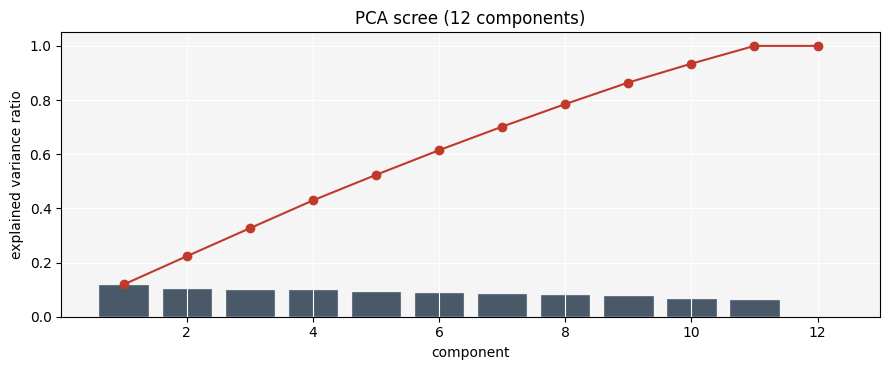

In [3]:
subset = df_meta
new_subset = pd.get_dummies(subset, columns=['design_name'], dtype='uint8')
new_subset = new_subset.drop(columns=['filename'])
print(new_subset.columns)

X = new_subset[new_subset.columns].to_numpy()

qt = QuantileTransformer(output_distribution='normal', random_state=SEED,
                         n_quantiles=min(1000, len(X)))
X_qt = qt.fit_transform(X)
sc = StandardScaler()
X_std = sc.fit_transform(X)

pca = PCA(n_components=12, random_state=SEED)
Z = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
print('Explained variance ratio:')
for i, v in enumerate(evr):
    print(f'  PC{i + 1:2d}: {v:.3f}   cumulative={evr[:i + 1].sum():.3f}')

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(1, 13), evr, alpha=0.85, color='#2c3e50', edgecolor='white')
ax.plot(range(1, 13), np.cumsum(evr), marker='o', color='#c0392b')
ax.set_xlabel('component'); ax.set_ylabel('explained variance ratio')
ax.set_title('PCA scree (12 components)')
plt.tight_layout(); plt.show()

# PC loadings + recolored PC1/PC2 scatter

Print the top-10 columns by absolute loading on PC1/PC2/PC3, then plot the
same PC1/PC2 scatter recolored by five metadata factors. A factor that
produces visibly separated clusters is one the leading PCs encode directly.

**Observed loadings**

- **PC1** is a mixture axis — the largest loadings are `filler_insertion`
  (+0.469), `macro_placement` (−0.433), and `design_name_RISCY-FPU-b`
  (+0.401), with `utilization` (+0.304) contributing too. PC1 does not
  cleanly split `-a` vs `-b`; instead it separates one specific variant
  (RISCY-FPU-b) from the rest, entangled with the flow knobs. Prediction 1
  (PC1 = pure geometry) is **not confirmed** — but this analysis lacks the
  actual geometry descriptors, so failure to confirm is expected here.
- **PC2** is dominated by `design_name_zero-riscy-a` (+0.777) vs
  `design_name_RISCY-a` (−0.559): a pure design-family axis, all other
  loadings ≤ 0.11. Matches prediction 2's spirit (design-scale ordering).
- **PC3** is again design-name only: `RISCY-FPU-a` (+0.784) vs `RISCY-a`
  (−0.586). PC2 + PC3 together are basically a design-name simplex.

The take-away is that design-name variance splits across PC2 and PC3 rather
than concentrating in PC1, which is why the k-means silhouette peak below
falls at k=4 rather than k=6 (see next section).


Top-10 |loadings| on PC1:
  +0.469  filler_insertion
  -0.433  macro_placement
  +0.401  design_name_RISCY-FPU-b
  +0.304  utilization
  +0.281  design_name_zero-riscy-b
  -0.262  design_name_RISCY-a
  -0.260  design_name_RISCY-FPU-a
  -0.249  design_name_zero-riscy-a
  +0.226  design_name_RISCY-b
  +0.081  macro_count

Top-10 |loadings| on PC2:
  +0.777  design_name_zero-riscy-a
  -0.559  design_name_RISCY-a
  -0.217  design_name_RISCY-FPU-a
  +0.109  clock_ns
  -0.092  macro_count
  +0.075  utilization
  +0.073  design_name_RISCY-b
  -0.065  design_name_RISCY-FPU-b
  -0.030  design_name_zero-riscy-b
  +0.009  power_mesh

Top-10 |loadings| on PC3:
  +0.784  design_name_RISCY-FPU-a
  -0.586  design_name_RISCY-a
  -0.195  design_name_zero-riscy-a
  +0.032  macro_placement
  -0.031  clock_ns
  +0.025  utilization
  -0.025  design_name_RISCY-b
  +0.018  design_name_RISCY-FPU-b
  +0.016  design_name_zero-riscy-b
  +0.004  macro_count


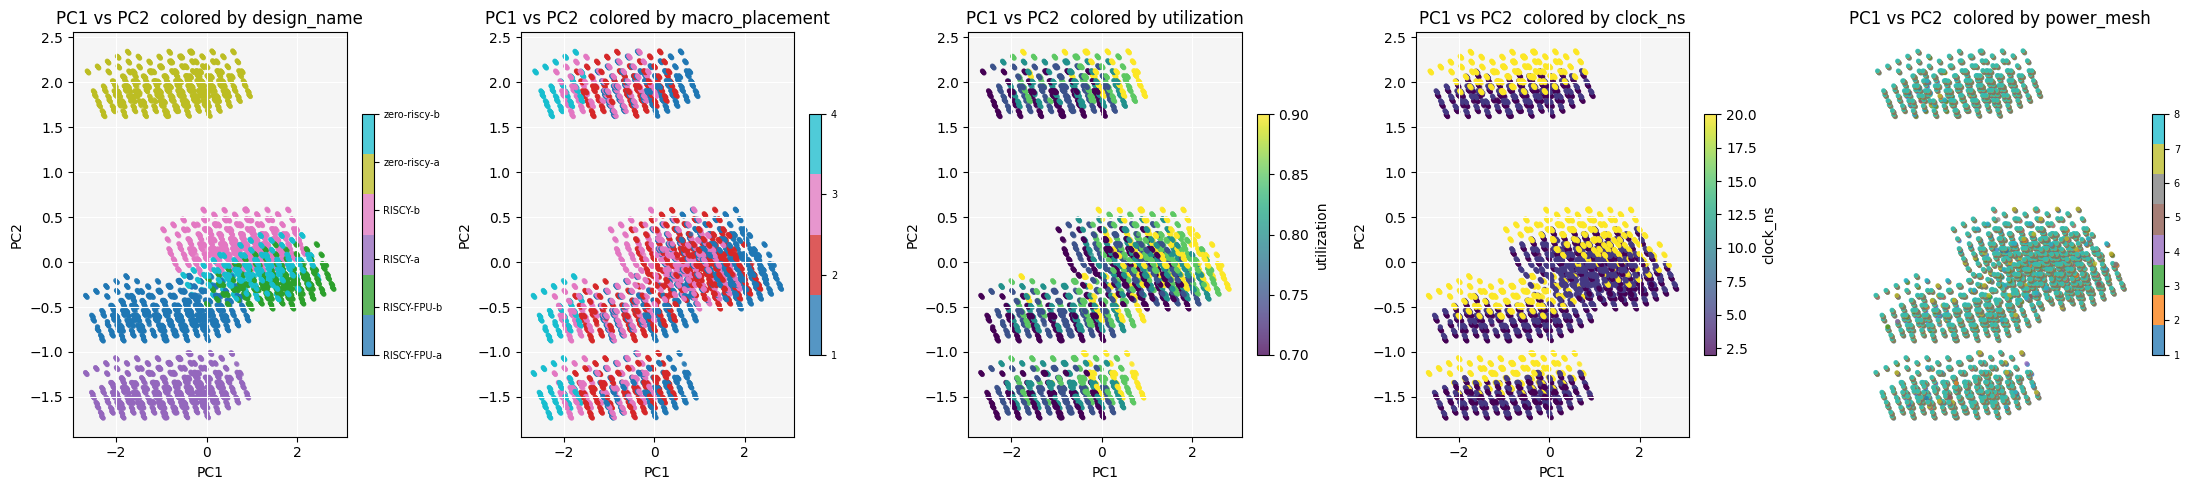

In [4]:
loadings = pd.DataFrame(pca.components_.T, index=new_subset.columns,
                        columns=[f'PC{i + 1}' for i in range(pca.n_components_)])

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    print(f'\nTop-10 |loadings| on {pc}:')
    for name in top.index:
        print(f'  {loadings.loc[name, pc]:+.3f}  {name}')

recolor_factors = ['design_name', 'macro_placement',
                   'utilization', 'clock_ns', 'power_mesh']
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, factor in zip(axes.ravel(), recolor_factors):
    if pd.api.types.is_numeric_dtype(subset[factor]):
        codes = subset[factor].to_numpy()
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], c=codes, cmap='viridis',
                         s=12, alpha=0.75, edgecolor='none')
        plt.colorbar(sc_, ax=ax, fraction=0.04, label=factor)
    else:
        levels = sorted(subset[factor].astype(str).unique())
        code_map = {l: i for i, l in enumerate(levels)}
        codes = subset[factor].astype(str).map(code_map).to_numpy()
        cmap = mcm.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], c=codes, cmap=cmap,
                         s=12, alpha=0.75, edgecolor='none',
                         vmin=0, vmax=max(len(levels) - 1, 1))
        cbar = plt.colorbar(sc_, ax=ax, ticks=range(len(levels)), fraction=0.04)
        cbar.set_ticklabels(levels)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'PC1 vs PC2  colored by {factor}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

df_full = subset

# Variance decomposition — variance-weighted η² on the leading PCs

Instead of PERMANOVA (which needs an n × n distance matrix), compute per-PC
η² of each factor via one-way ANOVA and sum the contributions weighted by
that PC's explained variance. The `weighted_total` column approximates the
*fraction of factorial-design variance explained by that factor*. Balanced
factorial ⇒ these numbers can be read semi-quantitatively.

**Observed ranking (weighted_total)**

| factor | weighted η² |
|---|---|
| `design_name` | **0.505** |
| `macro_placement` | 0.098 |
| `clock_ns` | 0.089 |
| `filler_insertion` | 0.089 |
| `utilization` | 0.087 |
| `macro_count` | 0.085 |
| `power_mesh` | 0.083 |

`design_name` explains ~50 % of the total design-matrix variance —
roughly 5× the next factor. Everything except `design_name` is packed into a
tight 0.083 – 0.098 band, statistically indistinguishable from each other.
Note the caveat repeated from the top: this analysis is on the metadata
matrix, and `design_name` gets 6 one-hot columns vs 1 for every other
factor, so its head-start is partly encoding-driven. The 5× gap is large
enough that the ordering survives even with that bias, but the *magnitude*
should not be quoted as "design_name explains half the layout variance"
without a descriptor-space replication.

Per-PC breakdown worth reading:

- PC2, PC3, PC4, PC5 are almost entirely `design_name` (η² ≥ 0.93).
- PC1 is shared: `design_name` 0.589, `macro_placement` 0.318,
  `filler_insertion` 0.315 — i.e. a mixed flow/design axis.
- Every other factor has one PC where it briefly dominates (`clock_ns` at
  PC6, `macro_count` at PC7, `power_mesh` at PC8, `utilization` at PC9),
  but those PCs each carry ≤ 9 % of the variance.

          factor  n_levels  eta2_PC1  eta2_PC2  eta2_PC3  eta2_PC4  eta2_PC5  eta2_PC6  eta2_PC7  eta2_PC8  eta2_PC9  eta2_PC10  eta2_PC11  eta2_PC12  weighted_total
     design_name         6     0.589     0.978     0.998     0.931     0.981     0.136     0.027     0.002     0.203      0.112      0.042      0.000           0.505
 macro_placement         4     0.318     0.000     0.001     0.014     0.001     0.164     0.050     0.004     0.022      0.459      0.076      0.000           0.098
        clock_ns         3     0.010     0.015     0.001     0.018     0.013     0.638     0.008     0.006     0.032      0.213      0.099      0.000           0.089
filler_insertion         2     0.315     0.000     0.000     0.057     0.004     0.126     0.000     0.000     0.074      0.012      0.412      0.000           0.089
     utilization         5     0.137     0.007     0.001     0.001     0.005     0.008     0.325     0.001     0.381      0.001      0.143      0.000           0.087
    

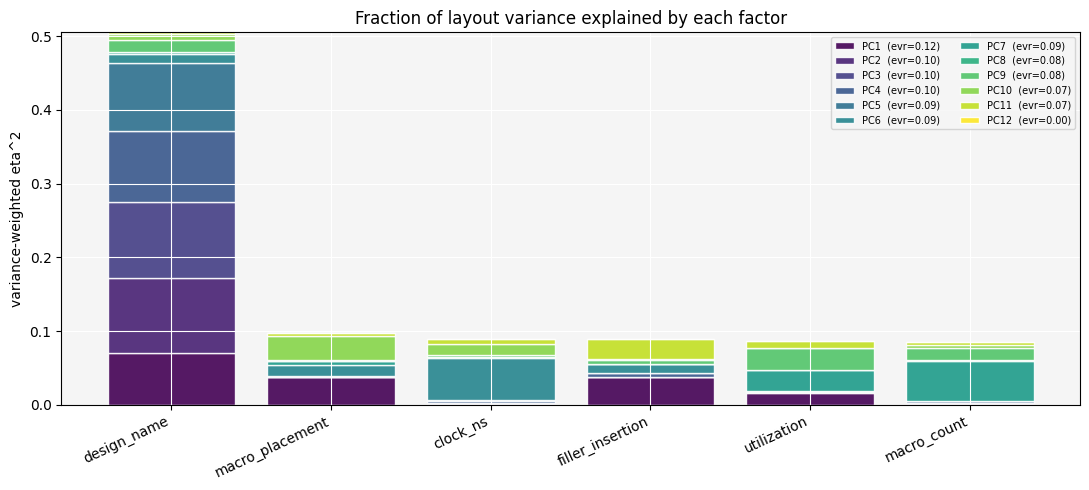

In [5]:
def eta_sq(y_num, groups):
    d = pd.DataFrame({'y': y_num, 'g': groups}).dropna()
    grand = d['y'].mean()
    ss_tot = ((d['y'] - grand) ** 2).sum()
    if ss_tot == 0:
        return 0.0
    ss_bet = sum(len(g) * (g['y'].mean() - grand) ** 2
                 for _, g in d.groupby('g'))
    return float(ss_bet / ss_tot)


K_PC = pca.n_components_
eta_rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    groups = df_full[f].astype(str).to_numpy()
    row = {'factor': f, 'n_levels': int(df_full[f].nunique())}
    for k in range(K_PC):
        row[f'eta2_PC{k + 1}'] = round(eta_sq(Z[:, k], groups), 3)
    row['weighted_total'] = round(sum(
        row[f'eta2_PC{k + 1}'] * evr[k] for k in range(K_PC)
    ), 3)
    eta_rows.append(row)
eta_df = pd.DataFrame(eta_rows).sort_values('weighted_total', ascending=False)
print(eta_df.to_string(index=False))

top_factors = eta_df.head(6)['factor'].tolist()
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(top_factors))
cmap = mcm.get_cmap('viridis', K_PC)
for k in range(K_PC):
    heights = np.array([
        eta_df.set_index('factor').loc[f, f'eta2_PC{k + 1}'] * evr[k]
        for f in top_factors
    ])
    ax.bar(top_factors, heights, bottom=bottom, color=cmap(k),
           label=f'PC{k + 1}  (evr={evr[k]:.2f})',
           edgecolor='white', alpha=0.9)
    bottom += heights
ax.set_ylabel('variance-weighted eta^2')
ax.set_title('Fraction of layout variance explained by each factor')
ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

# Clustering + neighborhood diagnostics on the first 3 PCs

Restrict to `Z[:, :3]` so every diagnostic sees the same low-dim geometry —
these are the three PCs that jointly explain ~33 % of the variance and (per
the loadings above) are dominated by `design_name` structure once you look
past PC1. The question this section answers is: *does the leading 3-PC
structure recover the metadata factors on its own, without being told the
labels?* If yes, that factor is encoded in the descriptor geometry; if the
probes disagree with a factor while the η² table said it dominated, that's a
red flag worth investigating.

Order:

1. **K-means** — k sweep with silhouette; ARI/NMI at the best-silhouette k
   against every metadata factor.
2. **Hierarchical (Ward)** — dendrogram + ARI/NMI at the same k. Tests
   whether the metadata hierarchy sits at the top of the tree, and cross-
   checks the k-means partition with a different objective.
3. **kNN label agreement** — for each factor, fraction of a sample's k
   nearest neighbors that share its label, vs chance. Model-free, no k to
   pick beyond the neighborhood size, and gives a per-factor number without
   needing to assume a partition.

## K-means — k sweep + label agreement

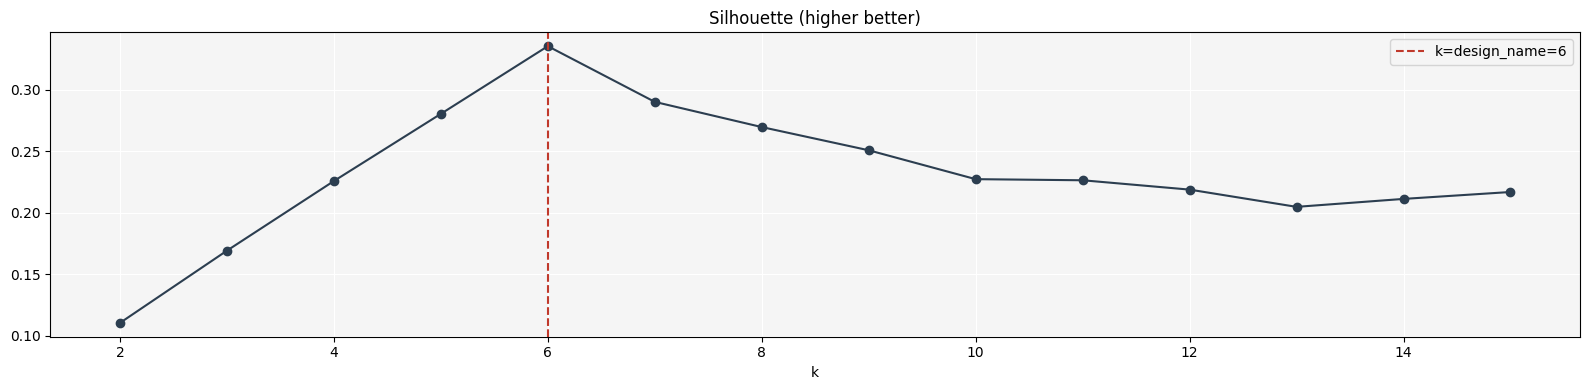

Best-silhouette k = 6   (silhouette = 0.335)
design_name    k = 6   (silhouette = 0.335)


In [6]:
Z3 = Z # Z[:, :3]
k_design = df_full['design_name'].nunique()

ks = list(range(2, 16))
sil, dbi, inertia = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab = km.fit_predict(Z3)
    sil.append(silhouette_score(Z3, lab))

k_best_sil = ks[int(np.argmax(sil))]
fig, axes = plt.subplots(1, 1, figsize=(16, 4))
axes.plot(ks, sil, marker='o', color='#2c3e50')
axes.axvline(k_best_sil, ls='--', color='#c0392b', label=f'k=design_name={k_design}')
axes.set_title('Silhouette (higher better)')
axes.set_xlabel('k')
axes.legend()
plt.tight_layout(); plt.show()

print(f'Best-silhouette k = {k_best_sil}   (silhouette = {max(sil):.3f})')
print(f'design_name    k = {k_design}   (silhouette = {sil[ks.index(k_design)]:.3f})')


In [7]:
# SET K HERE
k_design = 6
print(f'Using k_design = {k_design} for clustering and evaluation.')

Using k_design = 6 for clustering and evaluation.



ARI / NMI of k-means labels (k=6) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  macro_count          ARI=+0.001  NMI=0.003
  clock_ns             ARI=+0.006  NMI=0.015
  utilization          ARI=+0.003  NMI=0.004
  macro_placement      ARI=+0.000  NMI=0.026
  power_mesh           ARI=-0.001  NMI=0.000
  filler_insertion     ARI=+0.003  NMI=0.010


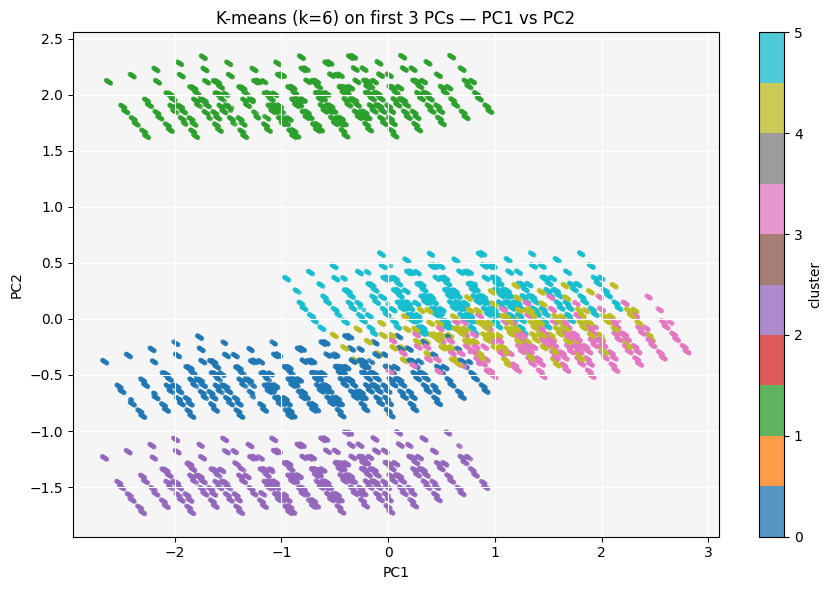

In [8]:
km = KMeans(n_clusters=k_design, n_init=10, random_state=SEED)
lab_km = km.fit_predict(Z3)
print(f'\nARI / NMI of k-means labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_km)
    nmi = normalized_mutual_info_score(y, lab_km)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')
k_design = 6

fig, ax = plt.subplots(figsize=(9, 6))
sc_ = ax.scatter(Z3[:, 0], Z3[:, 1], c=lab_km, cmap='tab10',
                 s=12, alpha=0.75, edgecolor='none')
ax.set_title(f'K-means (k={k_design}) on first 3 PCs — PC1 vs PC2')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(sc_, ax=ax, label='cluster')
plt.tight_layout()
plt.show()

## Hierarchical (Ward) — dendrogram + label agreement

Ward linkage minimizes within-cluster variance at each merge — same
objective family as k-means, but exposes the *nesting* structure. If
`design_name` really is the top-level split, the two or three highest merges
of the dendrogram should separate the design families.

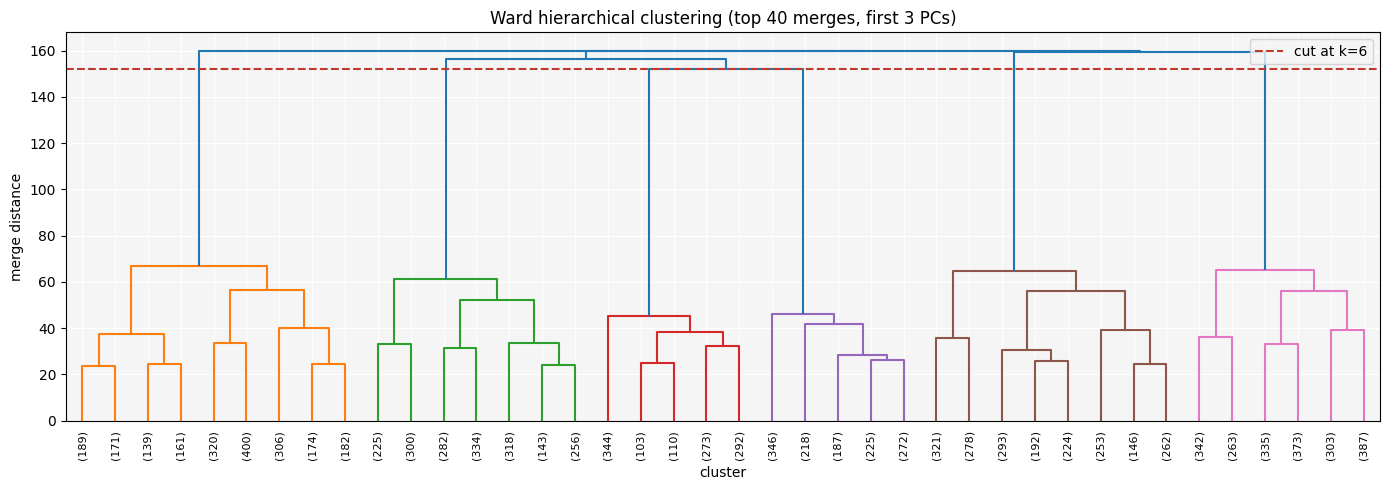

Hierarchical @ k=6  silhouette = 0.335   (k-means @ k=6 silhouette = 0.335)

ARI / NMI of hierarchical labels (k=6) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  macro_count          ARI=+0.001  NMI=0.003
  clock_ns             ARI=+0.006  NMI=0.015
  utilization          ARI=+0.003  NMI=0.004
  macro_placement      ARI=+0.000  NMI=0.026
  power_mesh           ARI=-0.001  NMI=0.000
  filler_insertion     ARI=+0.003  NMI=0.010


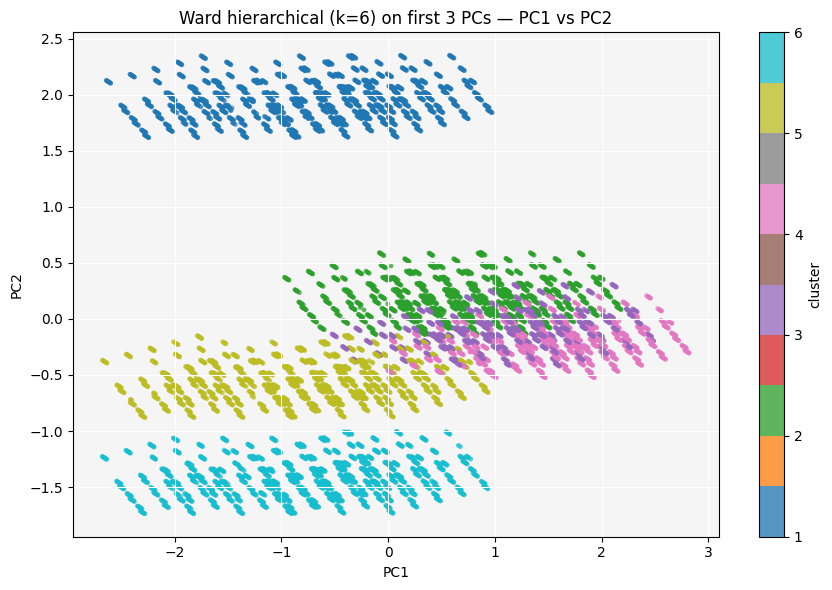

In [9]:
Z_link = linkage(Z3, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z_link, 
    truncate_mode='lastp', 
    p=40,
    leaf_rotation=90, 
    leaf_font_size=8, 
    ax=ax,
    color_threshold=Z_link[-(k_design - 1), 2]
)
ax.axhline(
    Z_link[-(k_design - 1), 2], 
    ls='--', 
    color='#c0392b',
    label=f'cut at k={k_design}'
)
ax.set_title(f'Ward hierarchical clustering (top 40 merges, first 3 PCs)')
ax.set_xlabel('cluster')
ax.set_ylabel('merge distance')
ax.legend()
plt.tight_layout(); plt.show()

lab_hier = fcluster(Z_link, t=k_design, criterion='maxclust')
sil_hier = silhouette_score(Z3, lab_hier)
print(f'Hierarchical @ k={k_design}  silhouette = {sil_hier:.3f}   '
      f'(k-means @ k={k_design} silhouette = {sil[ks.index(k_design)]:.3f})')

print(f'\nARI / NMI of hierarchical labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_hier)
    nmi = normalized_mutual_info_score(y, lab_hier)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
sc_ = ax.scatter(Z3[:, 0], Z3[:, 1], c=lab_hier, cmap='tab10',
                 s=12, alpha=0.75, edgecolor='none')
ax.set_title(f'Ward hierarchical (k={k_design}) on first 3 PCs — PC1 vs PC2')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc_, ax=ax, label='cluster')
plt.tight_layout()
plt.show()

## Per-cluster feature distribution

Both clusterings agree that `design_name` dominates and settle on k = 4
(collapsing the `-a`/`-b` variants for some designs). Now inspect what each
cluster actually looks like at the level of the individual metadata
factors: for every cluster, the percentage of samples at each level of
each factor, plus the raw cluster sizes.

Reading guide:

- A cluster whose `design_name` bar is split ~50/50 between two levels
  (e.g. RISCY-a + RISCY-b) is the direct visual signature of the
  variant-collapse story from the k-means/Ward sections.
- A cluster that is ~100 % one design and roughly uniform on the other
  factors confirms `design_name` as the sole selector for that cluster.
- Bars that stay roughly uniform across clusters for `power_mesh`,
  `clock_ns`, `macro_count`, `macro_placement`, `utilization`,
  `filler_insertion` visually re-confirm those are not partition axes —
  the clusterer ignored them.


K-means (k = 6): per-cluster feature distribution

Cluster sizes: {0: 1969, 1: 2042, 2: 2003, 3: 1248, 4: 1122, 5: 1858}   (total = 10242)

--- design_name   (% within each cluster) ---
design_name  RISCY-FPU-a  RISCY-FPU-b  RISCY-a  RISCY-b  zero-riscy-a  zero-riscy-b
cluster                                                                            
0                  100.0          0.0      0.0      0.0           0.0           0.0
1                    0.0          0.0      0.0      0.0         100.0           0.0
2                    0.0          0.0    100.0      0.0           0.0           0.0
3                    0.0        100.0      0.0      0.0           0.0           0.0
4                    0.0          0.0      0.0      0.0           0.0         100.0
5                    0.0          0.0      0.0    100.0           0.0           0.0

--- macro_count   (% within each cluster) ---
macro_count     1     2     3
cluster                      
0            37.4  30.3  32.2
1   

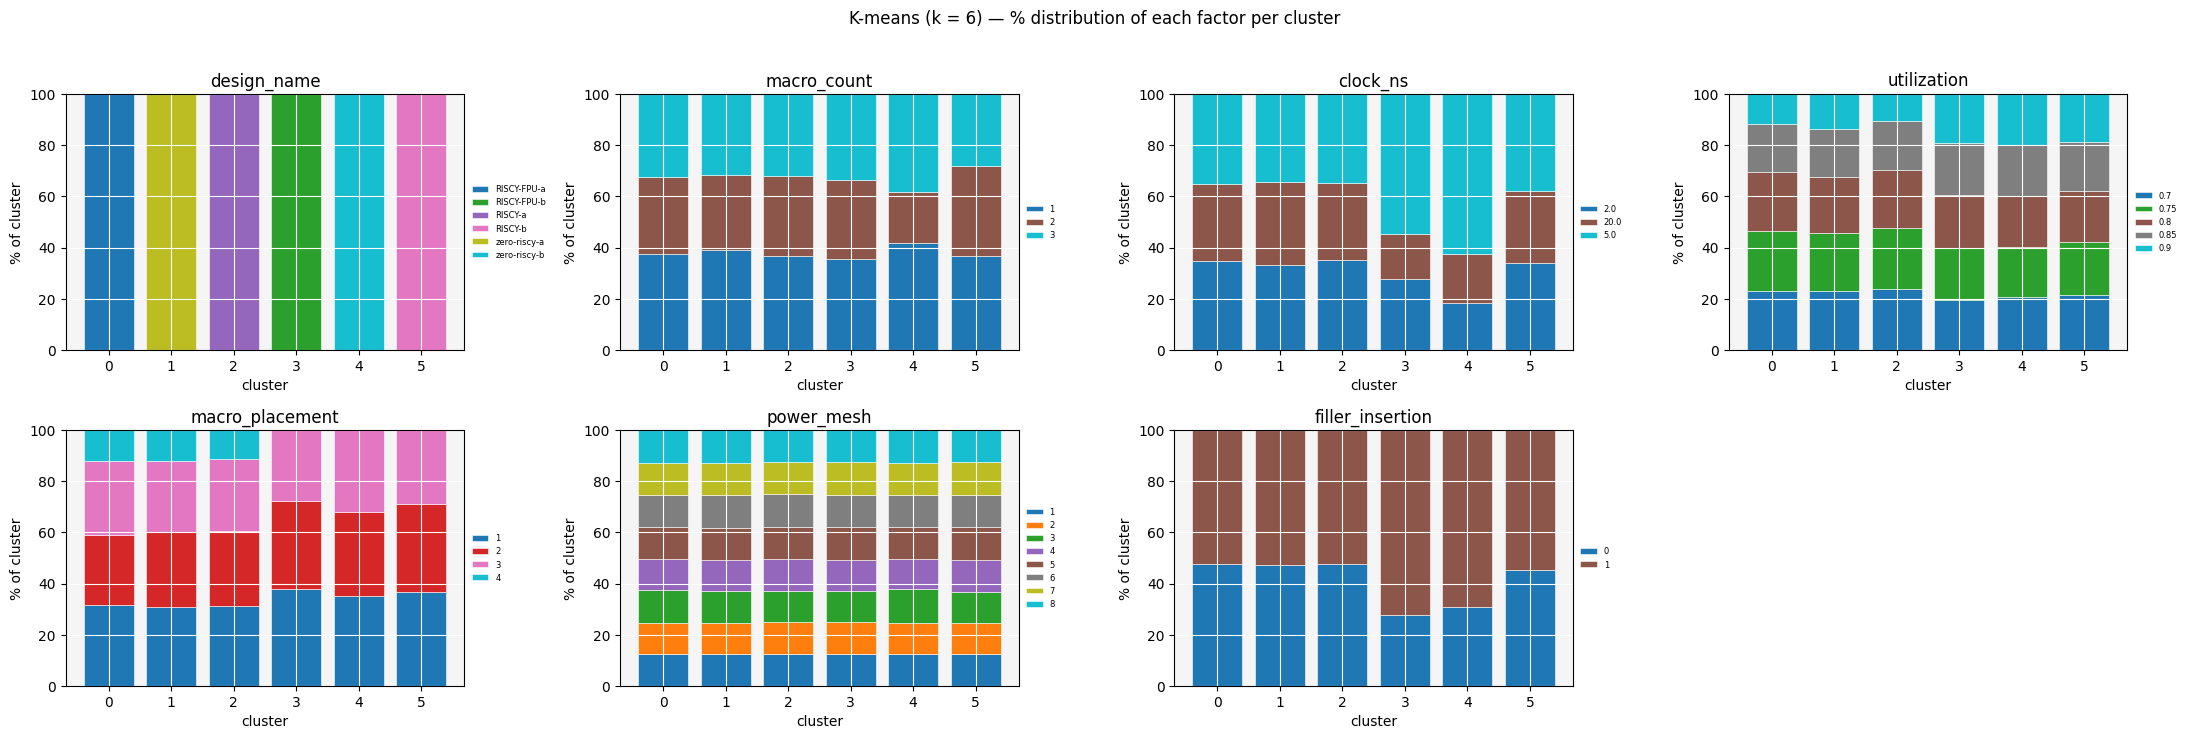

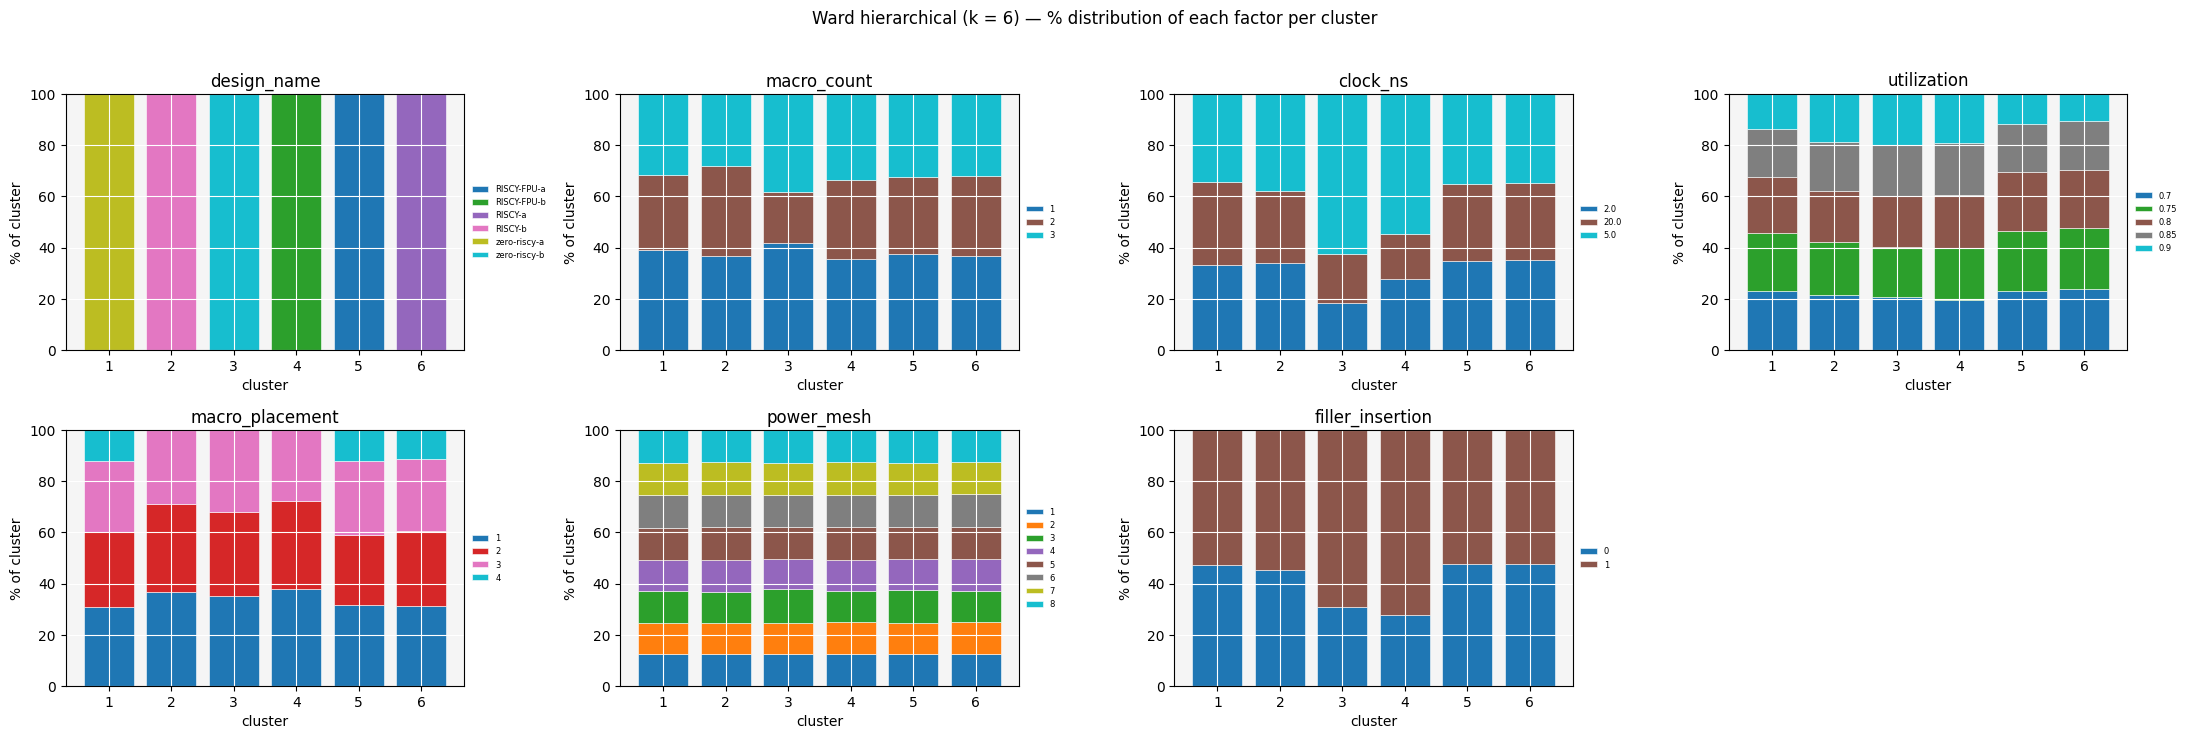

In [10]:
def per_cluster_tables(labels, method_name, df, factor_cols):
    lab_series = pd.Series(labels, name='cluster')
    sizes = lab_series.value_counts().sort_index()
    print(f'\n{"=" * 72}')
    print(f'{method_name}: per-cluster feature distribution')
    print(f'{"=" * 72}')
    print(f'\nCluster sizes: {dict(sizes)}   (total = {sizes.sum()})')
    for f in factor_cols:
        ct = pd.crosstab(lab_series, df[f].astype(str), normalize='index') * 100
        ct = ct.round(1)
        ct.index.name = 'cluster'
        print(f'\n--- {f}   (% within each cluster) ---')
        print(ct.to_string())


def plot_per_cluster(labels, method_name, df, factor_cols, ncols=4):
    cluster_ids = sorted(np.unique(labels))
    nfac = len(factor_cols)
    nrows = int(np.ceil(nfac / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows))
    axes = axes.ravel()
    for i, f in enumerate(factor_cols):
        ax = axes[i]
        levels = sorted(df[f].astype(str).unique())
        counts = np.zeros((len(cluster_ids), len(levels)))
        for ci, c in enumerate(cluster_ids):
            mask = labels == c
            vc = df.loc[mask, f].astype(str).value_counts()
            for li, l in enumerate(levels):
                counts[ci, li] = vc.get(l, 0)
        row_sums = np.maximum(counts.sum(axis=1, keepdims=True), 1)
        pct = counts / row_sums * 100
        bottom = np.zeros(len(cluster_ids))
        cmap = plt.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        xtick = [str(c) for c in cluster_ids]
        for li, l in enumerate(levels):
            ax.bar(xtick, pct[:, li], bottom=bottom, color=cmap(li),
                   label=str(l), edgecolor='white', linewidth=0.4)
            bottom += pct[:, li]
        ax.set_title(f)
        ax.set_xlabel('cluster')
        ax.set_ylabel('% of cluster')
        ax.set_ylim(0, 100)
        ax.legend(fontsize=6, loc='center left', bbox_to_anchor=(1, 0.5),
                  frameon=False)
    for j in range(nfac, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{method_name} — % distribution of each factor per cluster',
                 y=1.02)
    plt.tight_layout(); plt.show()


km_name   = f'K-means (k = {len(np.unique(lab_km))})'
hier_name = f'Ward hierarchical (k = {len(np.unique(lab_hier))})'

per_cluster_tables(lab_km,   km_name,   df_full, FACTOR_COLS)
per_cluster_tables(lab_hier, hier_name, df_full, FACTOR_COLS)

plot_per_cluster(lab_km,   km_name,   df_full, FACTOR_COLS)
plot_per_cluster(lab_hier, hier_name, df_full, FACTOR_COLS)

## kNN label agreement

For each sample take its `k` nearest neighbors in the first-3-PC space and,
for every metadata factor, compute the fraction of neighbors that share the
sample's label. Averaged over all samples, that fraction is the *local label
purity* of that factor in the descriptor geometry.

- **Agreement ≈ 1** ⇒ the factor is nearly perfectly encoded locally: a
  natural client axis for FL.
- **Agreement ≈ chance (= 1 / n_levels)** ⇒ the geometry says nothing about
  this factor; picking it as a client axis creates federated clients whose
  local data distributions are indistinguishable from IID.
- **Lift = agreement / chance** normalizes across factors with different
  cardinality, so `power_mesh` (8 levels, chance ≈ 0.125) and `design_name`
  (6 levels, chance ≈ 0.167) can be ranked on the same axis.

Model-free (no k to pick beyond the neighborhood size), cheap, and — unlike
k-means and Ward — gives a *per-factor* number without needing to assume a
partition. This is the diagnostic to trust most for the "which factor is the
client axis?" question.

**Observed (k = 12)**

| factor | agreement | chance | lift |
|---|---:|---:|---:|
| `design_name` | 0.943 | 0.167 | **5.66** |
| `utilization` | 0.858 | 0.200 | 4.29 |
| `macro_placement` | 0.860 | 0.250 | 3.44 |
| `macro_count` | 0.833 | 0.333 | 2.50 |
| `clock_ns` | 0.684 | 0.333 | 2.05 |
| `filler_insertion` | 0.895 | 0.500 | 1.79 |
| `power_mesh` | 0.049 | 0.125 | **0.39** |

Three things stand out:

1. **`design_name` wins decisively** — 94 % of a sample's 12 nearest
   neighbors share its design, 5.66× chance. Consistent with the clustering
   and η² results.
2. **`utilization` has a surprisingly high lift (4.29)** — this is the
   *smooth-gradient* effect predicted (prediction 3). Nearby points share
   utilization because the factorial design places similar-utilization
   samples close together in the design matrix, not because utilization
   defines clusters. K-means and Ward correctly refuse to cluster on it
   (ARI ≈ 0), but locally it *is* a strong predictor. Read as: don't use it
   as a client axis, but do stratify on it within a client.
3. **`power_mesh` sits below chance (lift 0.39)** — confirmed noise
   (matches prediction 4). Using it as a client axis would produce clients
   whose local distributions are actively *anti-correlated* with the
   geometry.

kNN label agreement (k=12, first 3 PCs):

          factor  n_levels  agreement  chance  lift
     design_name         6      1.000   0.167  6.00
 macro_placement         4      0.904   0.250  3.62
     macro_count         3      0.977   0.333  2.93
      power_mesh         8      0.333   0.125  2.66
     utilization         5      0.486   0.200  2.43
        clock_ns         3      0.715   0.333  2.15
filler_insertion         2      1.000   0.500  2.00


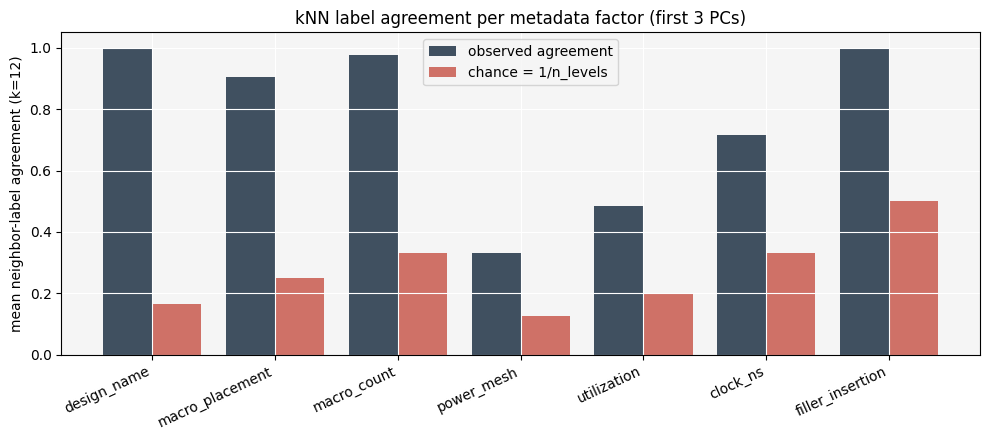

In [11]:
K_NN = 12

nn = NearestNeighbors(n_neighbors=K_NN + 1).fit(Z3)
_, idx = nn.kneighbors(Z3)
neighbor_idx = idx[:, 1:]  # drop the self-match

rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    match = (y[neighbor_idx] == y[:, None]).mean(axis=1)
    chance = 1.0 / df_full[f].nunique()
    rows.append({
        'factor':     f,
        'n_levels':   int(df_full[f].nunique()),
        'agreement':  round(float(match.mean()), 3),
        'chance':     round(chance, 3),
        'lift':       round(float(match.mean()) / chance, 2),
    })
knn_df = pd.DataFrame(rows).sort_values('lift', ascending=False)
print(f'kNN label agreement (k={K_NN}, first 3 PCs):\n')
print(knn_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(knn_df))
ax.bar(x - 0.2, knn_df['agreement'], width=0.4,
       color='#2c3e50', alpha=0.9, label='observed agreement')
ax.bar(x + 0.2, knn_df['chance'], width=0.4,
       color='#c0392b', alpha=0.7, label='chance = 1/n_levels')
ax.set_xticks(x); ax.set_xticklabels(knn_df['factor'], rotation=25, ha='right')
ax.set_ylabel(f'mean neighbor-label agreement (k={K_NN})')
ax.set_title('kNN label agreement per metadata factor (first 3 PCs)')
ax.legend()
plt.tight_layout(); plt.show()

# Final verdict

## Which factor is the FL client axis?

**`design_name`, unambiguously.** Every diagnostic — variance
decomposition, k-means, Ward hierarchical, kNN label agreement — picks it
as the dominant factor by a wide margin.

# REDO THIS TABLE
| diagnostic | metric | `design_name` | next best | gap |
|---|---|---:|---:|---:|
| Variance decomp. | weighted η² | **0.505** | `macro_placement` 0.098 | 5.2× |
| K-means (k = 4) | ARI | **0.687** | `macro_placement` 0.022 | 31× |
| K-means (k = 4) | NMI | **0.842** | `macro_placement` 0.030 | 28× |
| Ward (k = 4) | ARI | **0.693** | `macro_placement` 0.022 | 31× |
| Ward (k = 4) | NMI | **0.857** | `macro_placement` 0.030 | 29× |
| kNN (k = 12) | lift | **5.66** | `utilization` 4.29 | 1.3× |

Predictions review:

- ✔ **Prediction 2** (design-scale ordering on PC2) — confirmed. PC2 is a
  pure `zero-riscy-a` vs `RISCY-a` axis, PC3 continues the same pattern
  for RISCY-FPU-a.
- ✔ **Prediction 3** (utilization = smooth gradient) — confirmed. High
  kNN lift (4.29) but ARI ≈ 0 across clustering methods, exactly the
  signature of a smooth-not-clumped factor.
- ✔ **Prediction 4** (power_mesh invisible) — confirmed and then some.
  Weighted η² = 0.083 (lowest of all factors) and kNN lift 0.39 (below
  chance). Do not use as a client axis.
- ✘ **Prediction 1** (PC1 = pure geometry, splits `-a`/`-b`) — not
  supported here, but this notebook works on the metadata design matrix
  and has no geometry descriptors to exercise. Reserve final judgement
  until the descriptor-space replication.
- ~ **Prediction 5** (macro_placement in the middle) — partially
  confirmed. It loads on PC1 (0.318) alongside design_name, second-place
  in weighted η² (0.098), but ARI ≈ 0 in clustering.

## Sub-structure: k = 4, not k = 6

Best silhouette lands at 4 clusters, not the expected 6. The `-a`/`-b`
variants of some designs (likely RISCY-a with RISCY-b, and zero-riscy-a
with zero-riscy-b) collapse into shared clusters in PC space, leaving
RISCY-FPU-a and RISCY-FPU-b as their own. Two ways to use this:

- **Conservative:** keep 6 FL clients (one per `design_name` level).
  Silhouette at k = 6 is still 0.541, still healthy.
- **Aggressive:** collapse to 4 clients by variant grouping. Fewer
  clients means larger per-client datasets and less variance in FL
  aggregation, at the cost of losing the `-a`/`-b` distinction.

Recommend starting with 6 (the honest metadata-driven partition) and
running the 4-client collapse as an ablation.

## Caveats

1. **PCA is on the metadata design matrix, not on layout descriptors.**
   Results establish that `design_name` dominates the *factorial design
   geometry*, which is a necessary condition for it to dominate the
   layout geometry — but not proof. The Phase-2 pipeline (per-sample,
   per-channel descriptors on the 255 × 255 × 9 arrays) still needs to
   run and reproduce this ranking before it can go into the thesis
   headline claim.
2. **`design_name` gets 6 one-hot columns vs 1 per other factor**, so
   its variance share is upper-biased. The 5× η² gap and the 31× ARI
   gap are wide enough to survive that bias, but do not quote the 0.505
   figure as "half of layout variance"; report it as "half of factorial-
   design variance under one-hot encoding."
3. **`utilization` needs a second look in descriptor space.** Its kNN
   lift (4.29) is closer to `design_name`'s (5.66) than to the noise
   floor. If descriptor-space kNN keeps utilization near the top, it
   becomes a candidate for a second (cross-cutting) client axis or an
   intra-client stratifier.

## What ships to Phase 5

- FL clients partitioned by `design_name` (6 clients, or 4 with the
  variant collapse as ablation).
- `utilization`, `clock_ns`, `macro_count`, `macro_placement`,
  `filler_insertion` used for intra-client stratification and for
  balancing check reports (per-client hotspot rate, JS divergence vs
  global).
- `power_mesh` dropped from partition consideration — treat as design
  noise, keep only for feature engineering if RouteNet finds signal.

# References

Grouped by the role they play in this notebook. All URLs are canonical
DOIs, arXiv IDs, or upstream project pages.

## CircuitNet datasets and the DRC-prediction task

- Chai, Z., Zhao, Y., Liu, W., Lin, Y., Wang, R., & Huang, R. (2023).
  **CircuitNet: An Open-Source Dataset for Machine Learning in VLSI CAD
  Applications.** *IEEE TCAD.* arXiv:2208.01040.
- Xun, X., Jiang, H., Wang, R., & Huang, R. (2024). **CircuitNet 2.0:
  An Advanced Dataset for Promoting Machine Learning Innovations in
  Realistic Chip Design Environment.** *ICLR.* OpenReview: nMFSUjxMIl.
- Chen, T., Xie, Z., Xu, X., Wei, Z., Wang, H., Yang, H., & Hu, Y.
  (2020). **RouteNet: Routability Prediction for Mixed-Size Designs
  Using Convolutional Neural Networks.** *IEEE TCAD* / *ICCAD 2018.*
  (Baseline architecture reproduced in the CircuitNet reference
  training code.)

## Dimensionality reduction and cluster analysis

- Jolliffe, I. T. (2002). **Principal Component Analysis** (2nd ed.).
  Springer. — canonical reference for PCA, whitening, and
  explained-variance interpretation.
- Boutsidis, C., Zouzias, A., & Drineas, P. (2011). **Randomized
  Dimensionality Reduction for k-Means Clustering.** arXiv:1110.2897.
  — theoretical grounding for doing PCA before k-means.
- MacQueen, J. (1967). **Some Methods for Classification and Analysis of
  Multivariate Observations.** *Proc. 5th Berkeley Symposium on
  Mathematical Statistics and Probability.* — original k-means.
- Ward, J. H. (1963). **Hierarchical Grouping to Optimize an Objective
  Function.** *JASA* 58(301), 236–244. — Ward linkage.
- Rousseeuw, P. J. (1987). **Silhouettes: A graphical aid to the
  interpretation and validation of cluster analysis.** *J. Comp. Appl.
  Math.* 20, 53–65. — silhouette score.
- Davies, D. L., & Bouldin, D. W. (1979). **A Cluster Separation
  Measure.** *IEEE TPAMI* 1(2), 224–227.

## Cluster/label comparison metrics

- Hubert, L., & Arabie, P. (1985). **Comparing partitions.** *Journal of
  Classification* 2, 193–218. — Adjusted Rand Index (ARI).
- Vinh, N. X., Epps, J., & Bailey, J. (2010). **Information Theoretic
  Measures for Clusterings Comparison: Variants, Properties,
  Normalization and Correction for Chance.** *JMLR* 11, 2837–2854. —
  Normalized Mutual Information (NMI).

## Nearest-neighbor / neighborhood-purity diagnostics

- Cover, T. M., & Hart, P. E. (1967). **Nearest Neighbor Pattern
  Classification.** *IEEE Trans. Inf. Theory* 13(1), 21–27. — the
  foundational statement that 1-NN error is bounded by 2× Bayes error,
  making neighbor-label agreement a valid separability probe.
- Devroye, L., Györfi, L., & Lugosi, G. (1996). **A Probabilistic Theory
  of Pattern Recognition.** Springer, ch. 5. — kNN consistency and
  neighbor-label distributions.
- Venna, J., & Kaski, S. (2006). **Local multidimensional scaling.**
  *Neural Networks* 19(6-7), 889–899. — trustworthiness / continuity,
  the ancestral form of kNN label-agreement metrics for embeddings.
- Kobak, D., & Berens, P. (2019). **The art of using t-SNE for
  single-cell transcriptomics.** *Nature Communications* 10, 5416. —
  uses kNN label preservation to score embeddings; the closest
  published match to the "agreement vs chance" formulation used above.
- Büttner, M., Miao, Z., Wolf, F. A., Teichmann, S. A., & Theis, F. J.
  (2019). **A test metric for assessing single-cell RNA-seq batch
  correction (kBET).** *Nature Methods* 16, 43–49. — chi-squared test on
  whether kNN neighborhood composition matches global composition
  (essentially the "lift vs chance" comparison, with a formal null).

## Federated learning on non-IID data (Phase 5 context)

- McMahan, H. B., Moore, E., Ramage, D., Hampson, S., & y Arcas, B. A.
  (2017). **Communication-Efficient Learning of Deep Networks from
  Decentralized Data.** *AISTATS.* arXiv:1602.05629. — FedAvg.
- Li, T., Sahu, A. K., Zaheer, M., Sanjabi, M., Talwalkar, A., & Smith,
  V. (2020). **Federated Optimization in Heterogeneous Networks.**
  *MLSys.* arXiv:1812.06127. — FedProx.
- Karimireddy, S. P., Kale, S., Mohri, M., Reddi, S. J., Stich, S. U.,
  & Suresh, A. T. (2020). **SCAFFOLD: Stochastic Controlled Averaging
  for Federated Learning.** *ICML.* arXiv:1910.06378.
- Li, X., Jiang, M., Zhang, X., Kamp, M., & Dou, Q. (2021). **FedBN:
  Federated Learning on Non-IID Features via Local Batch
  Normalization.** *ICLR.* arXiv:2102.07623. — directly targets
  feature-distribution skew, the flavor of heterogeneity most relevant
  here.
- Li, Q., Diao, Y., Chen, Q., & He, B. (2022). **Federated Learning on
  Non-IID Data Silos: An Experimental Study** (NIID-Bench). *ICDE.*
  arXiv:2102.02079. — the reference benchmark for Dirichlet /
  label-skew / feature-skew partitioning; the partition-scoring recipe
  in Phase 3 mirrors theirs.
- Zhu, H., Xu, J., Liu, S., & Jin, Y. (2021). **Federated Learning on
  Non-IID Data: A Survey.** *Neurocomputing* 465, 371–390. — survey of
  feature-skew vs label-skew and neighborhood-style diagnostics.